# Stage 5 — Treatment Effect Heterogeneity

## Research question

**Which types of users experience the largest incremental increase in visit probability because of advertising?**

Stage 4 showed that a causal forest can rank users. Stage 5 asks a harder question: is that apparent heterogeneity reproducible, statistically defensible, and simple enough to describe as an audience strategy?

The estimand remains

$$\tau(x)=E[Y(1)-Y(0)\mid X=x].$$

Because the features are anonymized, we cannot attach demographic stories to them. We can still identify reproducible feature-defined segments and evaluate their effects directly in randomized data.

## Analysis design: discovery and confirmation must be separated

This notebook uses three disjoint samples:

1. **Training:** fit the causal forest and choose important heterogeneity features.
2. **Validation:** explore bins and discover simple segment rules.
3. **Test:** estimate treatment effects for those locked segments exactly once.

This separation matters. If we search hundreds of subgroups and report the best effect from the same data, the winner will usually be exaggerated. Here the test set confirms rules selected without seeing its outcomes.

The notebook distinguishes three forms of evidence:

- **Prediction evidence:** the distribution of forest CATE estimates.
- **Ranking evidence:** whether higher predicted CATE corresponds to higher experimental uplift.
- **Subgroup evidence:** direct treated-minus-control effects inside pre-specified segments.

In [1]:
from pathlib import Path
import platform
import sys
import time
import warnings

import econml
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from sklearn import __version__ as sklearn_version
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text
from econml.dml import CausalForestDML

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='X does not have valid feature names.*')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

print('Python       :', platform.python_version())
print('Executable   :', Path(sys.executable).name)
print('NumPy        :', np.__version__)
print('pandas       :', pd.__version__)
print('scikit-learn:', sklearn_version)
print('LightGBM     :', lgb.__version__)
print('EconML       :', econml.__version__)

Python       : 3.10.19
Executable   : python
NumPy        : 2.2.6
pandas       : 2.3.2
scikit-learn: 1.7.1
LightGBM     : 4.6.0
EconML       : 0.17.0


## 1. Reproduce the Stage 4 sample and split

The full file is streamed in chunks and the same fixed approximately one-million-row sample is recreated. We preserve the same 60/20/20 split and use a 400,000-row stratified training subset for the forest.

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'criteo-uplift-v2.1.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find data/criteo-uplift-v2.1.csv.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'data' / 'criteo-uplift-v2.1.csv'
FEATURES = [f'f{i}' for i in range(12)]
TARGET = 'visit'
KEEP_COLS = FEATURES + ['treatment', 'visit', 'conversion']
DTYPES = {
    **{c: 'float32' for c in FEATURES},
    'treatment': 'int8',
    'visit': 'int8',
    'conversion': 'int8',
}

EXPECTED_ROWS = 13_979_592
SAMPLE_TARGET = 1_000_000
CHUNK_SIZE = 500_000
RANDOM_SEED = 42
sample_probability = SAMPLE_TARGET / EXPECTED_ROWS

start = time.perf_counter()
rng = np.random.default_rng(RANDOM_SEED)
parts = []
rows_scanned = 0
for chunk in pd.read_csv(DATA_PATH, usecols=KEEP_COLS, dtype=DTYPES, chunksize=CHUNK_SIZE):
    rows_scanned += len(chunk)
    keep = rng.random(len(chunk)) < sample_probability
    parts.append(chunk.loc[keep].copy())

df = pd.concat(parts, ignore_index=True)
elapsed = time.perf_counter() - start
print(f'Scanned {rows_scanned:,} rows in {elapsed:.1f} seconds.')
print(f'Modeling sample: {len(df):,} rows; memory {df.memory_usage(deep=True).sum()/1024**2:.1f} MiB.')

Scanned 13,979,592 rows in 11.2 seconds.
Modeling sample: 999,453 rows; memory 48.6 MiB.


In [3]:
strata = df['treatment'].astype(str) + '_' + df[TARGET].astype(str)
train_df, temp_df = train_test_split(
    df, test_size=0.40, random_state=RANDOM_SEED, stratify=strata
)
temp_strata = temp_df['treatment'].astype(str) + '_' + temp_df[TARGET].astype(str)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=RANDOM_SEED, stratify=temp_strata
)
train_strata = train_df['treatment'].astype(str) + '_' + train_df[TARGET].astype(str)
forest_train, _ = train_test_split(
    train_df, train_size=400_000, random_state=RANDOM_SEED + 10, stratify=train_strata
)

split_summary = pd.concat({
    name: frame.groupby('treatment')[TARGET].agg(['size', 'sum', 'mean'])
    for name, frame in [('training', forest_train), ('validation', valid_df), ('test', test_df)]
}, names=['split', 'treatment'])
display(split_summary)

assert forest_train.index.intersection(valid_df.index).empty
assert forest_train.index.intersection(test_df.index).empty
assert valid_df.index.intersection(test_df.index).empty
assert not set(['treatment', 'visit', 'conversion', 'exposure']).intersection(FEATURES)
print('All samples are disjoint and no outcome or treatment variable is used as a feature.')

size    sum     mean
split      treatment                        
training   0           59831   2219 0.037088
           1          340169  16529 0.048591
validation 0           29899   1109 0.037092
           1          169992   8260 0.048591
test       0           29900   1109 0.037090
           1          169991   8260 0.048591

All samples are disjoint and no outcome or treatment variable is used as a feature.


## 2. Fit the honest causal forest

Treatment assignment is randomized, so a constant-prior propensity model is appropriate. A flexible treatment model would mostly learn chance imbalance. LightGBM models the outcome nuisance; the forest uses two-fold cross-fitting and honest tree construction.

In [4]:
def make_outcome_model(seed):
    return lgb.LGBMClassifier(
        objective='binary',
        n_estimators=180,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=200,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1,
    )

X_train = forest_train[FEATURES].to_numpy(dtype=np.float32)
y_train = forest_train[TARGET].to_numpy(dtype=np.int8)
t_train = forest_train['treatment'].to_numpy(dtype=np.int8)
X_valid = valid_df[FEATURES].to_numpy(dtype=np.float32)
X_test = test_df[FEATURES].to_numpy(dtype=np.float32)

causal_forest = CausalForestDML(
    model_y=make_outcome_model(RANDOM_SEED + 20),
    model_t=DummyClassifier(strategy='prior'),
    discrete_outcome=True,
    discrete_treatment=True,
    categories=[0, 1],
    cv=2,
    n_estimators=200,
    criterion='mse',
    max_depth=15,
    min_samples_leaf=200,
    max_samples=0.45,
    honest=True,
    inference=True,
    subforest_size=4,
    n_jobs=-1,
    random_state=RANDOM_SEED + 20,
)

start = time.perf_counter()
causal_forest.fit(y_train, t_train, X=X_train, inference='auto')
fit_seconds = time.perf_counter() - start
cate_valid = np.asarray(causal_forest.effect(X_valid)).reshape(-1)
cate_test = np.asarray(causal_forest.effect(X_test)).reshape(-1)

print(f'Fit time: {fit_seconds:.1f} seconds')
print(f'Validation predictions: {len(cate_valid):,}; test predictions: {len(cate_test):,}')

Fit time: 44.1 seconds
Validation predictions: 199,891; test predictions: 199,891


## 3. CATE distribution: evidence of model variation, not proof of true variation

A wide prediction distribution may reflect real heterogeneity, model noise, or both. We first check whether the distribution looks similar across validation and test covariates. Later sections use randomized outcomes to determine whether the ranking and segments reproduce.

,validation,test
mean,0.006720,0.006740
std,0.018890,0.018990
p01,-0.010017,-0.010190
p10,-0.000683,-0.000655
p25,0.000267,0.000266
median,0.000729,0.000725
p75,0.005050,0.004985
p90,0.016802,0.016825
p99,0.109008,0.109622
share_positive,0.839237,0.840083


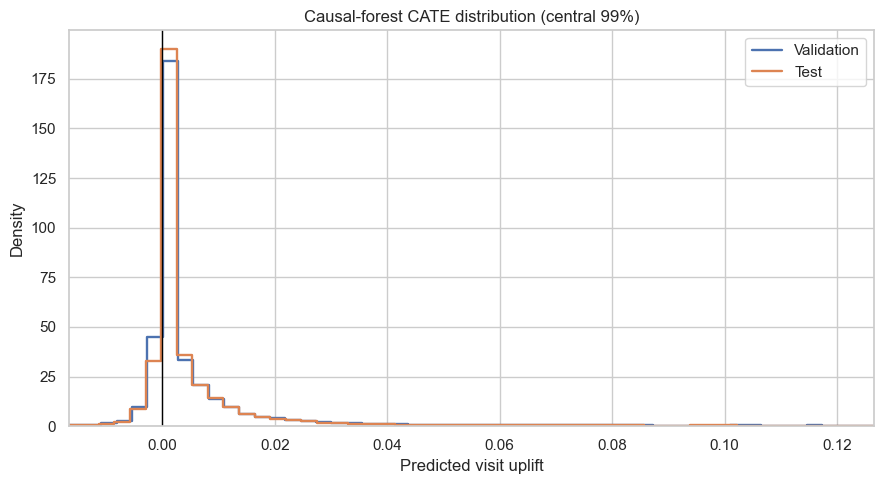

In [5]:
def cate_description(score):
    return pd.Series({
        'mean': np.mean(score),
        'std': np.std(score),
        'p01': np.quantile(score, .01),
        'p10': np.quantile(score, .10),
        'p25': np.quantile(score, .25),
        'median': np.quantile(score, .50),
        'p75': np.quantile(score, .75),
        'p90': np.quantile(score, .90),
        'p99': np.quantile(score, .99),
        'share_positive': np.mean(score > 0),
    })

cate_summary = pd.concat({
    'validation': cate_description(cate_valid),
    'test': cate_description(cate_test),
}, axis=1)
display(cate_summary)

plot_low = min(np.quantile(cate_valid, .005), np.quantile(cate_test, .005))
plot_high = max(np.quantile(cate_valid, .995), np.quantile(cate_test, .995))
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(cate_valid, bins=80, stat='density', element='step', fill=False, linewidth=1.7, label='Validation', ax=ax)
sns.histplot(cate_test, bins=80, stat='density', element='step', fill=False, linewidth=1.7, label='Test', ax=ax)
ax.axvline(0, color='black', linewidth=1)
ax.set(xlim=(plot_low, plot_high), title='Causal-forest CATE distribution (central 99%)', xlabel='Predicted visit uplift')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Best linear predictor calibration on the randomized test set

With randomized propensity p, the transformed outcome

$$Z=\frac{TY}{p}-\frac{(1-T)Y}{1-p}$$

satisfies $E[Z\mid X]=\tau(X)$. We regress Z on the centered forest score with HC3 robust standard errors.

- The intercept estimates average uplift.
- A positive slope indicates that larger forest scores correspond to larger realized causal effects.
- A slope of one is the ideal level-calibration benchmark.

This signal is deliberately noisy—especially because only 15% of users are controls—but it gives an honest model-level calibration diagnostic.

In [6]:
def hc3_blp(signal, score):
    centered = np.asarray(score) - np.mean(score)
    design = np.column_stack([np.ones(len(centered)), centered])
    xtx_inv = np.linalg.inv(design.T @ design)
    coef = xtx_inv @ design.T @ signal
    residual = signal - design @ coef
    leverage = np.einsum('ij,jk,ik->i', design, xtx_inv, design)
    hc3_sq = (residual / (1 - leverage)) ** 2
    meat = design.T @ (design * hc3_sq[:, None])
    covariance = xtx_inv @ meat @ xtx_inv
    standard_error = np.sqrt(np.diag(covariance))
    z_stat = coef / standard_error
    p_value = 2 * stats.norm.sf(np.abs(z_stat))
    return pd.Series({
        'intercept_ATE': coef[0],
        'intercept_se': standard_error[0],
        'slope': coef[1],
        'slope_se': standard_error[1],
        'slope_ci_95_low': coef[1] - 1.96 * standard_error[1],
        'slope_ci_95_high': coef[1] + 1.96 * standard_error[1],
        'slope_p_value': p_value[1],
        'effect_change_per_1sd_score': coef[1] * np.std(score),
    })

y_test = test_df[TARGET].to_numpy(dtype=np.int8)
t_test = test_df['treatment'].to_numpy(dtype=np.int8)
propensity = t_train.mean()
transformed_outcome = t_test * y_test / propensity - (1 - t_test) * y_test / (1 - propensity)
blp_result = hc3_blp(transformed_outcome, cate_test)
display(blp_result.to_frame(name='estimate'))
print(f'Randomized training propensity used in the score: {propensity:.4f}')

,estimate
intercept_ATE,0.011499
intercept_se,0.001232
slope,2.183456
slope_se,0.149806
slope_ci_95_low,1.889837
slope_ci_95_high,2.477074
slope_p_value,0.000000
effect_change_per_1sd_score,0.041464


Randomized training propensity used in the score: 0.8504


## 5. Which features organize the forest's heterogeneity?

Forest importance is used only as a training-sample screening device. It describes which variables the forest used for treatment-effect splits. It is not a causal effect of the feature, and correlated features can substitute for one another.

We lock the top four features before examining validation or test outcomes.

,heterogeneity_importance
f6,0.303215
f3,0.289663
f8,0.181541
f9,0.161157
f2,0.025820
f0,0.021413
f10,0.008782
f7,0.006188
f4,0.001217
f11,0.000382


Locked top-four features: ['f6', 'f3', 'f8', 'f9']


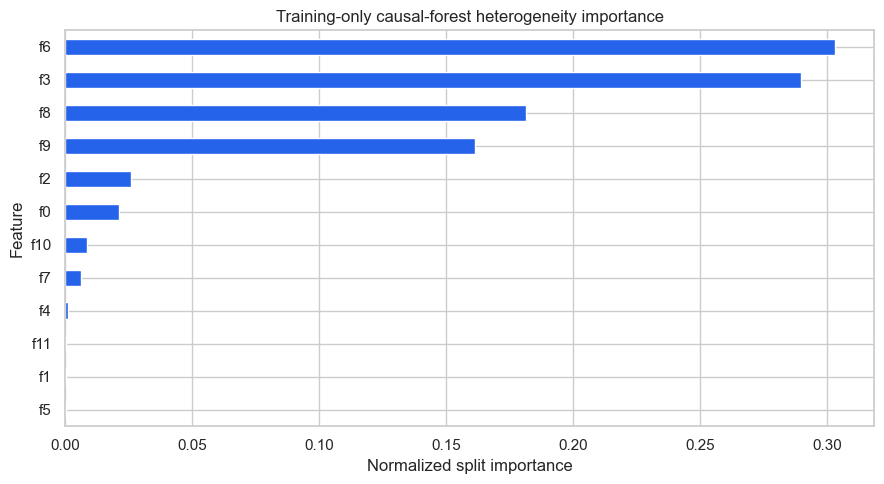

In [7]:
feature_importance = pd.Series(
    causal_forest.feature_importances_, index=FEATURES, name='heterogeneity_importance'
).sort_values(ascending=False)
top_features = feature_importance.head(4).index.tolist()
display(feature_importance.to_frame())
print('Locked top-four features:', top_features)

fig, ax = plt.subplots(figsize=(9, 5))
feature_importance.sort_values().plot.barh(ax=ax, color='#2563eb')
ax.set(title='Training-only causal-forest heterogeneity importance', xlabel='Normalized split importance', ylabel='Feature')
plt.tight_layout()
plt.show()

## 6. Tie-aware feature bins and randomized subgroup effects

Many anonymized Criteo features have large point masses. Arbitrarily breaking identical values into equal-sized quantiles would create fake distinctions. We therefore derive candidate cut points from training quantiles, remove duplicate and boundary values, and preserve ties.

For each locked feature, the same training-derived bin boundaries are applied to validation and test. Effects within each bin are estimated directly from randomized treated and control users.

,split,feature,bin,lower_exclusive,upper_inclusive,users,treated_n,control_n,effect,se,ci_95_low,ci_95_high
0,validation,f6,1,-inf,-10.987528,20285,17527,2758,0.046546,0.006260,0.034275,0.058816
1,validation,f6,2,-10.987528,-6.699321,31525,26727,4798,0.013456,0.003382,0.006828,0.020085
2,validation,f6,3,-6.699321,-2.411115,62960,53463,9497,0.006339,0.001579,0.003244,0.009435
3,validation,f6,4,-2.411115,inf,85121,72275,12846,0.004436,0.001733,0.001039,0.007832
4,test,f6,1,-inf,-10.987528,20657,17816,2841,0.069005,0.005785,0.057667,0.080343
5,test,f6,2,-10.987528,-6.699321,31192,26614,4578,0.017383,0.003290,0.010935,0.023831
6,test,f6,3,-6.699321,-2.411115,63166,53618,9548,0.003814,0.001608,0.000662,0.006966
7,test,f6,4,-2.411115,inf,84876,71943,12933,-0.000384,0.001819,-0.003948,0.003181
8,validation,f3,1,-inf,2.587543,20343,17630,2713,0.066617,0.006452,0.053972,0.079262
9,validation,f3,2,2.587543,inf,179548,152362,27186,0.004092,0.001146,0.001847,0.006338


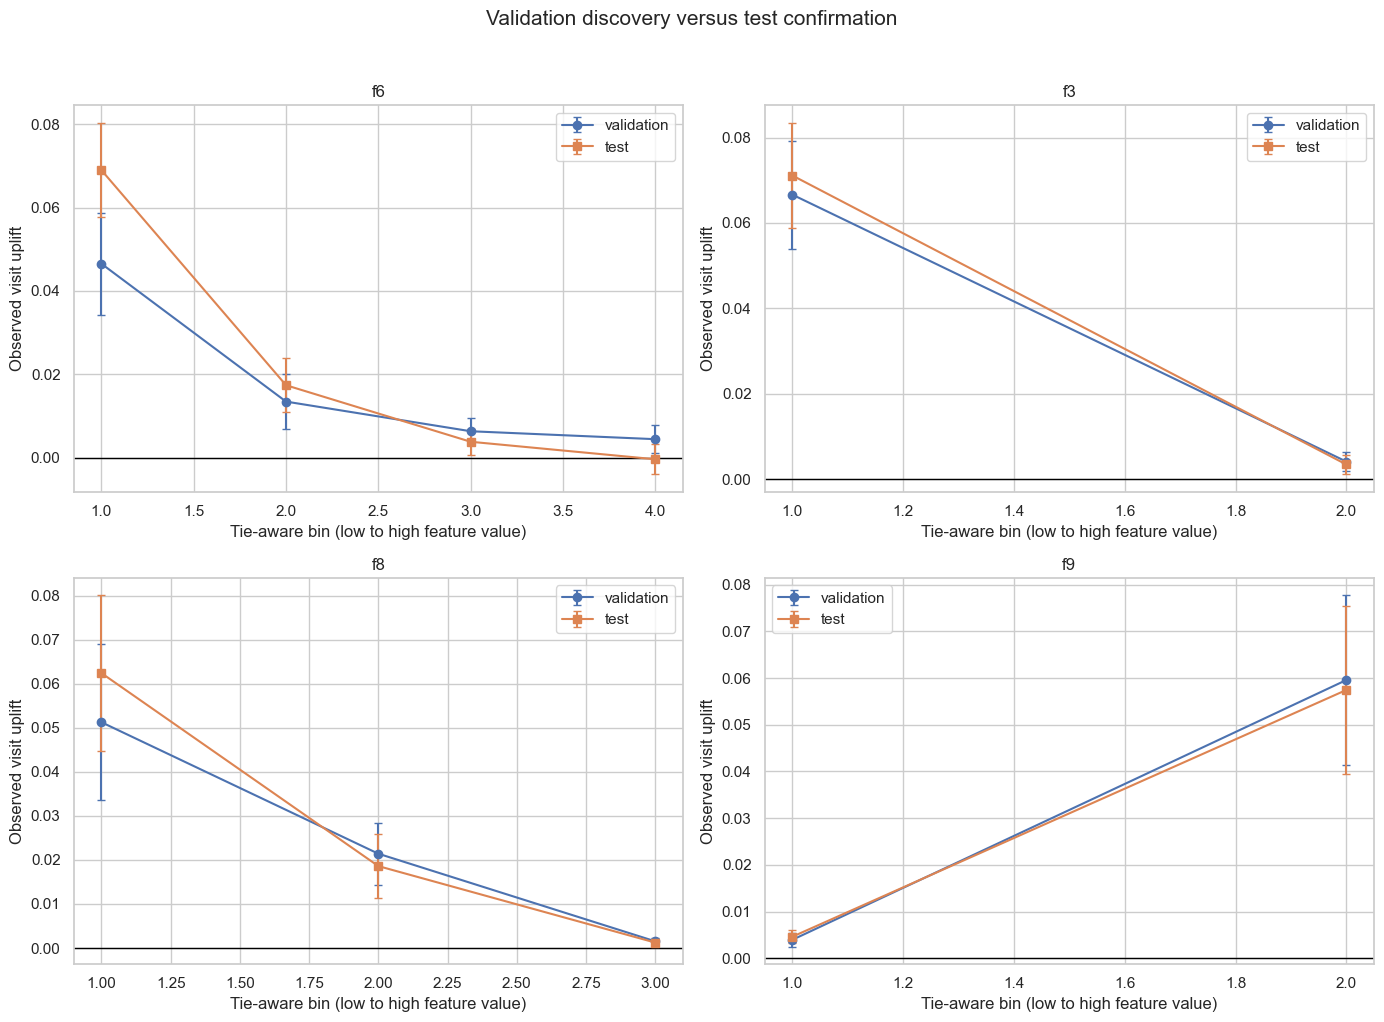

In [8]:
def effect_and_se(frame):
    treated = frame.loc[frame['treatment'].eq(1), TARGET].to_numpy()
    control = frame.loc[frame['treatment'].eq(0), TARGET].to_numpy()
    pt, pc = treated.mean(), control.mean()
    effect = pt - pc
    se = np.sqrt(pt * (1 - pt) / len(treated) + pc * (1 - pc) / len(control))
    return effect, se, len(treated), len(control)

def tie_aware_edges(values):
    values = np.asarray(values)
    minimum, maximum = np.min(values), np.max(values)
    candidates = np.unique(np.quantile(values, [.10, .25, .50, .75, .90]))
    interior = candidates[(candidates > minimum) & (candidates < maximum)]
    return np.r_[-np.inf, interior, np.inf]

def bin_effect_table(frame, feature, edges, split_name):
    bin_id = np.digitize(frame[feature].to_numpy(), edges[1:-1], right=True)
    rows = []
    for b in np.unique(bin_id):
        group = frame.loc[bin_id == b]
        effect, se, treated_n, control_n = effect_and_se(group)
        rows.append({
            'split': split_name,
            'feature': feature,
            'bin': int(b + 1),
            'lower_exclusive': edges[b],
            'upper_inclusive': edges[b + 1],
            'users': len(group),
            'treated_n': treated_n,
            'control_n': control_n,
            'effect': effect,
            'se': se,
            'ci_95_low': effect - 1.96 * se,
            'ci_95_high': effect + 1.96 * se,
        })
    return pd.DataFrame(rows)

feature_edges = {feature: tie_aware_edges(forest_train[feature]) for feature in top_features}
effect_tables = []
for feature in top_features:
    effect_tables.append(bin_effect_table(valid_df, feature, feature_edges[feature], 'validation'))
    effect_tables.append(bin_effect_table(test_df, feature, feature_edges[feature], 'test'))
feature_bin_effects = pd.concat(effect_tables, ignore_index=True)
display(feature_bin_effects)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feature in zip(axes.flat, top_features):
    for split_name, marker in [('validation', 'o'), ('test', 's')]:
        part = feature_bin_effects.loc[
            feature_bin_effects['feature'].eq(feature) & feature_bin_effects['split'].eq(split_name)
        ]
        ax.errorbar(part['bin'], part['effect'], yerr=1.96 * part['se'], marker=marker, capsize=3, label=split_name)
    ax.axhline(0, color='black', linewidth=1)
    ax.set(title=feature, xlabel='Tie-aware bin (low to high feature value)', ylabel='Observed visit uplift')
    ax.legend()
plt.suptitle('Validation discovery versus test confirmation', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

## 7. Formal heterogeneity checks with multiple-testing control

Two complementary tests are reported:

- A Cochran-style Q test asks whether all test-bin effects for a feature are equal.
- Validation selects that feature's highest- and lowest-uplift bins; the locked contrast is then estimated on test.

Because four features are examined, Holm-adjusted p-values control the family-wise error rate. Statistical significance is not the only criterion—effect size, interval width, stability, and segment size also matter.

In [9]:
def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    sorted_p = p_values[order]
    adjusted_sorted = np.maximum.accumulate((len(p_values) - np.arange(len(p_values))) * sorted_p)
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = np.minimum(adjusted_sorted, 1.0)
    return adjusted

confirmation_rows = []
for feature in top_features:
    valid_part = feature_bin_effects.loc[
        feature_bin_effects['feature'].eq(feature) & feature_bin_effects['split'].eq('validation')
    ].copy()
    test_part = feature_bin_effects.loc[
        feature_bin_effects['feature'].eq(feature) & feature_bin_effects['split'].eq('test')
    ].copy()

    high_bin = int(valid_part.loc[valid_part['effect'].idxmax(), 'bin'])
    low_bin = int(valid_part.loc[valid_part['effect'].idxmin(), 'bin'])
    high_test = test_part.loc[test_part['bin'].eq(high_bin)].iloc[0]
    low_test = test_part.loc[test_part['bin'].eq(low_bin)].iloc[0]
    contrast = high_test['effect'] - low_test['effect']
    contrast_se = np.sqrt(high_test['se'] ** 2 + low_test['se'] ** 2)
    contrast_p = 2 * stats.norm.sf(abs(contrast / contrast_se))

    weights = 1 / test_part['se'].to_numpy() ** 2
    effects = test_part['effect'].to_numpy()
    common_effect = np.average(effects, weights=weights)
    q_stat = np.sum(weights * (effects - common_effect) ** 2)
    q_df = len(effects) - 1
    q_p = stats.chi2.sf(q_stat, q_df)

    confirmation_rows.append({
        'feature': feature,
        'validation_selected_high_bin': high_bin,
        'validation_selected_low_bin': low_bin,
        'test_high_bin_effect': high_test['effect'],
        'test_low_bin_effect': low_test['effect'],
        'test_high_minus_low': contrast,
        'contrast_ci_95_low': contrast - 1.96 * contrast_se,
        'contrast_ci_95_high': contrast + 1.96 * contrast_se,
        'contrast_p_raw': contrast_p,
        'Q_stat': q_stat,
        'Q_df': q_df,
        'Q_p_raw': q_p,
    })

heterogeneity_tests = pd.DataFrame(confirmation_rows).set_index('feature')
heterogeneity_tests['contrast_p_Holm'] = holm_adjust(heterogeneity_tests['contrast_p_raw'])
heterogeneity_tests['Q_p_Holm'] = holm_adjust(heterogeneity_tests['Q_p_raw'])
heterogeneity_tests['contrast_confirmed_5pct'] = heterogeneity_tests['contrast_p_Holm'] < .05
heterogeneity_tests['Q_confirmed_5pct'] = heterogeneity_tests['Q_p_Holm'] < .05
display(heterogeneity_tests.sort_values('contrast_p_Holm'))

,validation_selected_high_bin,validation_selected_low_bin,test_high_bin_effect,test_low_bin_effect,test_high_minus_low,contrast_ci_95_low,contrast_ci_95_high,contrast_p_raw,Q_stat,Q_df,Q_p_raw,contrast_p_Holm,Q_p_Holm,contrast_confirmed_5pct,Q_confirmed_5pct
feature,,,,,,,,,,,,,,,
f6,1,4,0.069005,-0.000384,0.069389,0.057504,0.081274,0.000000,144.743641,3,0.000000,0.000000,0.000000,True,True
f3,1,2,0.071108,0.003414,0.067693,0.055162,0.080225,0.000000,112.094037,1,0.000000,0.000000,0.000000,True,True
f8,1,3,0.062432,0.001229,0.061203,0.043539,0.078868,0.000000,67.734382,2,0.000000,0.000000,0.000000,True,True
f9,2,1,0.057434,0.004610,0.052824,0.034754,0.070894,0.000000,32.828042,1,0.000000,0.000000,0.000000,True,True


## 8. High-uplift and low-uplift model-defined audiences

Validation CATE thresholds define high (top 10%), middle, and low (bottom 10%) audiences. The thresholds are frozen and transferred to test, so test outcomes do not influence membership.

The profile heatmap describes associations between anonymized features and forest-defined audiences. It should not be interpreted as saying that changing a feature would change ad effectiveness.

,test_share,users,treated_n,control_n,mean_predicted_cate,observed_uplift,ci_95_low,ci_95_high
audience,,,,,,,,
High predicted uplift,0.100135,20016,17396,2620,0.050964,0.076424,0.060157,0.092691
Middle,0.801287,160170,135882,24288,0.002579,0.000623,-0.001239,0.002485
Low predicted uplift,0.098579,19705,16713,2992,-0.004367,0.008013,-0.000935,0.016960


,test_confirmation
high_minus_low_effect,0.068411
ci_95_low,0.049846
ci_95_high,0.086977
p_value,0.000000


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11
High predicted uplift,-0.644259,0.649835,0.215876,-1.673235,0.847066,-0.902237,-1.288919,0.677823,-1.788471,1.652657,0.745360,-0.600982
Middle,0.154230,-0.070867,-0.095681,0.180762,-0.100850,0.093069,0.090614,-0.064958,0.251355,-0.213852,-0.093187,0.069545
Low predicted uplift,-0.599221,-0.084146,0.558448,0.230341,-0.040667,0.159956,0.572721,-0.160516,-0.226411,0.059530,0.000325,0.045175


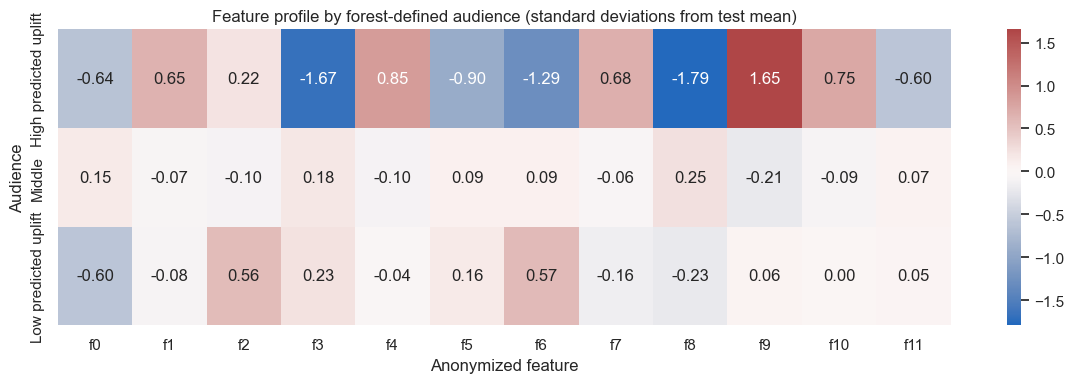

In [10]:
low_threshold, high_threshold = np.quantile(cate_valid, [.10, .90])
test_audience = np.where(cate_test >= high_threshold, 'High predicted uplift',
                         np.where(cate_test <= low_threshold, 'Low predicted uplift', 'Middle'))

audience_rows = []
audience_masks = {}
for audience in ['High predicted uplift', 'Middle', 'Low predicted uplift']:
    mask = test_audience == audience
    audience_masks[audience] = mask
    effect, se, treated_n, control_n = effect_and_se(test_df.loc[mask])
    audience_rows.append({
        'audience': audience,
        'test_share': mask.mean(),
        'users': int(mask.sum()),
        'treated_n': treated_n,
        'control_n': control_n,
        'mean_predicted_cate': cate_test[mask].mean(),
        'observed_uplift': effect,
        'ci_95_low': effect - 1.96 * se,
        'ci_95_high': effect + 1.96 * se,
        'se': se,
    })
audience_effects = pd.DataFrame(audience_rows).set_index('audience')
display(audience_effects.drop(columns='se'))

high_row = audience_effects.loc['High predicted uplift']
low_row = audience_effects.loc['Low predicted uplift']
high_low_difference = high_row['observed_uplift'] - low_row['observed_uplift']
high_low_se = np.sqrt(high_row['se'] ** 2 + low_row['se'] ** 2)
high_low_p = 2 * stats.norm.sf(abs(high_low_difference / high_low_se))
high_low_test = pd.Series({
    'high_minus_low_effect': high_low_difference,
    'ci_95_low': high_low_difference - 1.96 * high_low_se,
    'ci_95_high': high_low_difference + 1.96 * high_low_se,
    'p_value': high_low_p,
}, name='test_confirmation')
display(high_low_test.to_frame())

feature_mean = test_df[FEATURES].mean()
feature_std = test_df[FEATURES].std().replace(0, np.nan)
profile = pd.DataFrame({
    audience: (test_df.loc[mask, FEATURES].mean() - feature_mean) / feature_std
    for audience, mask in audience_masks.items()
}).T
display(profile)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(profile, center=0, cmap='vlag', annot=True, fmt='.2f', ax=ax)
ax.set(title='Feature profile by forest-defined audience (standard deviations from test mean)', xlabel='Anonymized feature', ylabel='Audience')
plt.tight_layout()
plt.show()

## 9. Convert a complex forest into an interpretable segment tree

A depth-three surrogate tree is fitted on validation covariates to approximate validation CATE predictions. This tree is not a new causal estimator; it is a compression tool that converts a complex ranking into a small set of auditable rules.

Rules and leaf ranking are discovered on validation. Their actual treatment effects are confirmed on test using randomized treated-minus-control comparisons.

In [11]:
segment_tree = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=15_000,
    random_state=RANDOM_SEED + 60,
)
segment_tree.fit(valid_df[top_features], cate_valid)
print(export_text(segment_tree, feature_names=top_features, decimals=3))

valid_leaf = segment_tree.apply(valid_df[top_features])
test_leaf = segment_tree.apply(test_df[top_features])

def leaf_effect_summary(frame, leaf_ids, predicted_cate, split_name):
    rows = []
    for leaf in np.unique(leaf_ids):
        mask = leaf_ids == leaf
        effect, se, treated_n, control_n = effect_and_se(frame.loc[mask])
        rows.append({
            'split': split_name,
            'leaf_id': int(leaf),
            'users': int(mask.sum()),
            'share': mask.mean(),
            'treated_n': treated_n,
            'control_n': control_n,
            'mean_predicted_cate': np.mean(predicted_cate[mask]),
            'observed_uplift': effect,
            'se': se,
            'ci_95_low': effect - 1.96 * se,
            'ci_95_high': effect + 1.96 * se,
        })
    return pd.DataFrame(rows)

valid_leaves = leaf_effect_summary(valid_df, valid_leaf, cate_valid, 'validation')
test_leaves = leaf_effect_summary(test_df, test_leaf, cate_test, 'test')
leaf_ranking = valid_leaves.sort_values('mean_predicted_cate', ascending=False)['leaf_id'].tolist()
leaf_names = {leaf: f'Segment {rank + 1}' for rank, leaf in enumerate(leaf_ranking)}

leaf_comparison = valid_leaves.merge(
    test_leaves, on='leaf_id', suffixes=('_validation', '_test')
)
leaf_comparison['segment'] = leaf_comparison['leaf_id'].map(leaf_names)
leaf_comparison['validation_rank'] = leaf_comparison['leaf_id'].map({leaf: rank + 1 for rank, leaf in enumerate(leaf_ranking)})
leaf_comparison = leaf_comparison.sort_values('validation_rank').set_index('segment')
display(leaf_comparison[[
    'leaf_id', 'validation_rank', 'share_validation', 'mean_predicted_cate_validation',
    'observed_uplift_validation', 'share_test', 'mean_predicted_cate_test',
    'observed_uplift_test', 'ci_95_low_test', 'ci_95_high_test'
]])

|--- f3 <= 2.167
|   |--- value: [0.044]
|--- f3 >  2.167
|   |--- f8 <= 3.859
|   |   |--- value: [0.016]
|   |--- f8 >  3.859
|   |   |--- f8 <= 3.918
|   |   |   |--- value: [0.007]
|   |   |--- f8 >  3.918
|   |   |   |--- value: [0.001]



,leaf_id,validation_rank,share_validation,mean_predicted_cate_validation,observed_uplift_validation,share_test,mean_predicted_cate_test,observed_uplift_test,ci_95_low_test,ci_95_high_test
segment,,,,,,,,,,
Segment 1,1,1,0.081895,0.044151,0.069580,0.083090,0.043928,0.076994,0.062668,0.091320
Segment 2,3,2,0.098699,0.015700,0.020432,0.096908,0.015973,0.027608,0.011073,0.044144
Segment 3,5,3,0.124428,0.006631,0.012541,0.123487,0.006525,0.008990,0.002324,0.015656
Segment 4,6,4,0.694979,0.001050,0.001117,0.696515,0.001056,0.000662,-0.000213,0.001536


Locked top-segment rule: f3 <= 2.167


,value
top_segment_leaf_id,1.000000
top_segment_test_share,0.083090
top_segment_test_uplift,0.076994
top_segment_test_ci_low,0.062668
top_segment_test_ci_high,0.091320
rest_test_uplift,0.004427
top_minus_rest,0.072567
top_minus_rest_ci_low,0.058063
top_minus_rest_ci_high,0.087071
top_minus_rest_p_value,0.000000


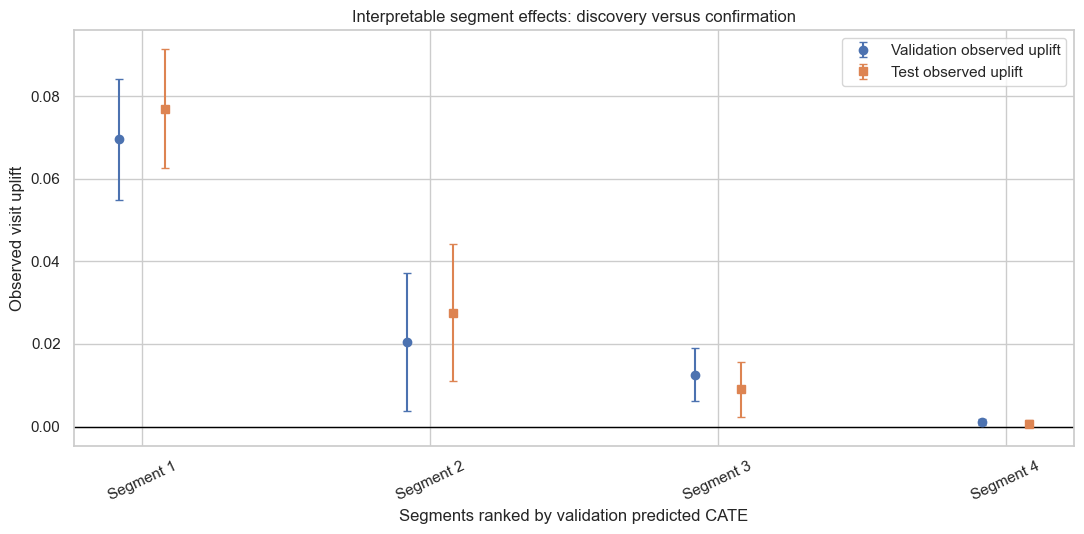

In [12]:
top_leaf = leaf_ranking[0]

def describe_leaf_rule(model, feature_names, leaf_id):
    tree = model.tree_
    parent = np.full(tree.node_count, -1, dtype=int)
    arrived_from_left = np.zeros(tree.node_count, dtype=bool)
    for node in range(tree.node_count):
        left, right = tree.children_left[node], tree.children_right[node]
        if left != -1:
            parent[left] = node
            arrived_from_left[left] = True
        if right != -1:
            parent[right] = node
            arrived_from_left[right] = False
    conditions = []
    node = int(leaf_id)
    while parent[node] != -1:
        parent_node = parent[node]
        feature = feature_names[tree.feature[parent_node]]
        operator = '<=' if arrived_from_left[node] else '>'
        conditions.append(f'{feature} {operator} {tree.threshold[parent_node]:.3f}')
        node = parent_node
    return ' AND '.join(reversed(conditions))

top_segment_rule = describe_leaf_rule(segment_tree, top_features, top_leaf)
print('Locked top-segment rule:', top_segment_rule)
top_leaf_mask = test_leaf == top_leaf
top_leaf_effect, top_leaf_se, _, _ = effect_and_se(test_df.loc[top_leaf_mask])
rest_effect, rest_se, _, _ = effect_and_se(test_df.loc[~top_leaf_mask])
top_vs_rest = top_leaf_effect - rest_effect
top_vs_rest_se = np.sqrt(top_leaf_se ** 2 + rest_se ** 2)
top_vs_rest_p = 2 * stats.norm.sf(abs(top_vs_rest / top_vs_rest_se))

leaf_rank_stability = stats.spearmanr(
    leaf_comparison['mean_predicted_cate_validation'],
    leaf_comparison['observed_uplift_test'],
).statistic
segment_confirmation = pd.Series({
    'top_segment_leaf_id': top_leaf,
    'top_segment_test_share': top_leaf_mask.mean(),
    'top_segment_test_uplift': top_leaf_effect,
    'top_segment_test_ci_low': top_leaf_effect - 1.96 * top_leaf_se,
    'top_segment_test_ci_high': top_leaf_effect + 1.96 * top_leaf_se,
    'rest_test_uplift': rest_effect,
    'top_minus_rest': top_vs_rest,
    'top_minus_rest_ci_low': top_vs_rest - 1.96 * top_vs_rest_se,
    'top_minus_rest_ci_high': top_vs_rest + 1.96 * top_vs_rest_se,
    'top_minus_rest_p_value': top_vs_rest_p,
    'leaf_rank_spearman_validation_to_test': leaf_rank_stability,
    'top_segment_policy_value_per_1k': 1000 * top_leaf_mask.mean() * top_leaf_effect,
}, name='value')
display(segment_confirmation.to_frame())

plot_table = leaf_comparison.sort_values('validation_rank')
x = np.arange(len(plot_table))
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.errorbar(x - .08, plot_table['observed_uplift_validation'], yerr=1.96 * plot_table['se_validation'], fmt='o', capsize=3, label='Validation observed uplift')
ax.errorbar(x + .08, plot_table['observed_uplift_test'], yerr=1.96 * plot_table['se_test'], fmt='s', capsize=3, label='Test observed uplift')
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x, plot_table.index, rotation=25)
ax.set(title='Interpretable segment effects: discovery versus confirmation', xlabel='Segments ranked by validation predicted CATE', ylabel='Observed visit uplift')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Automatically generated findings

The following summary is populated from the executed notebook so the narrative remains tied to the actual results.

In [13]:
confirmed_features = heterogeneity_tests.index[heterogeneity_tests['contrast_confirmed_5pct']].tolist()
confirmed_text = ', '.join(confirmed_features) if confirmed_features else 'none of the four screened features'
strongest_feature = heterogeneity_tests['contrast_p_Holm'].idxmin()
strongest_row = heterogeneity_tests.loc[strongest_feature]
high_effect = audience_effects.loc['High predicted uplift']
low_effect = audience_effects.loc['Low predicted uplift']

display(Markdown(f'''### Main findings

- Validation and test CATE distributions are similar: test mean **{cate_test.mean():.3%}**, standard deviation **{cate_test.std():.3%}**, with **{np.mean(cate_test > 0):.1%}** positive point predictions. This is prediction variation, not yet proof of individual-level causal variation.
- The randomized transformed-outcome calibration slope is **{blp_result.slope:.2f}** (95% CI **{blp_result.slope_ci_95_low:.2f} to {blp_result.slope_ci_95_high:.2f}**, p = **{blp_result.slope_p_value:.3g}**). A positive slope supports ranking signal. Because the slope is above one, the forest appears to compress the separation between low- and high-effect users.
- Training-only forest importance selected **{', '.join(top_features)}**. After validation discovery, test confirmation, and Holm correction, the high-versus-low bin contrast is significant for **{confirmed_text}**.
- The strongest feature-bin confirmation is **{strongest_feature}**: test high-minus-low uplift **{strongest_row.test_high_minus_low:.3%}** (95% CI **{strongest_row.contrast_ci_95_low:.3%} to {strongest_row.contrast_ci_95_high:.3%}**, Holm p = **{strongest_row.contrast_p_Holm:.3g}**).
- The validation-defined high-CATE audience covers **{high_effect.test_share:.1%}** of test users and has observed uplift **{high_effect.observed_uplift:.3%}** (95% CI **{high_effect.ci_95_low:.3%} to {high_effect.ci_95_high:.3%}**). The low-CATE audience has **{low_effect.observed_uplift:.3%}** (95% CI **{low_effect.ci_95_low:.3%} to {low_effect.ci_95_high:.3%}**). Their confirmed difference is **{high_low_difference:.3%}** (95% CI **{high_low_difference-1.96*high_low_se:.3%} to {high_low_difference+1.96*high_low_se:.3%}**, p = **{high_low_p:.3g}**).
- The validation-derived surrogate tree's locked top rule is **{top_segment_rule}**. It covers **{top_leaf_mask.mean():.1%}** of test users, with test uplift **{top_leaf_effect:.3%}** (95% CI **{top_leaf_effect-1.96*top_leaf_se:.3%} to {top_leaf_effect+1.96*top_leaf_se:.3%}**). Its policy value is **{1000*top_leaf_mask.mean()*top_leaf_effect:.2f} incremental visits per 1,000 eligible users**.
- The top tree segment exceeds the rest of the population by **{top_vs_rest:.3%}** (95% CI **{top_vs_rest-1.96*top_vs_rest_se:.3%} to {top_vs_rest+1.96*top_vs_rest_se:.3%}**, p = **{top_vs_rest_p:.3g}**). Across the tree's **{len(leaf_comparison)} leaves**, validation predicted-CATE ranking versus test observed uplift has Spearman correlation **{leaf_rank_stability:.3f}**; with so few leaves, treat this as descriptive rather than a precise generalization metric.

The defensible conclusion is about reproducible group-average differences and policy value—not about knowing any individual's counterfactual response.
'''))

### Main findings

- Validation and test CATE distributions are similar: test mean **0.674%**, standard deviation **1.899%**, with **84.0%** positive point predictions. This is prediction variation, not yet proof of individual-level causal variation.
- The randomized transformed-outcome calibration slope is **2.18** (95% CI **1.89 to 2.48**, p = **4.04e-48**). A positive slope supports ranking signal. Because the slope is above one, the forest appears to compress the separation between low- and high-effect users.
- Training-only forest importance selected **f6, f3, f8, f9**. After validation discovery, test confirmation, and Holm correction, the high-versus-low bin contrast is significant for **f6, f3, f8, f9**.
- The strongest feature-bin confirmation is **f6**: test high-minus-low uplift **6.939%** (95% CI **5.750% to 8.127%**, Holm p = **1.02e-29**).
- The validation-defined high-CATE audience covers **10.0%** of test users and has observed uplift **7.642%** (95% CI **6.016% to 9.269%**). The low-CATE audience has **0.801%** (95% CI **-0.093% to 1.696%**). Their confirmed difference is **6.841%** (95% CI **4.985% to 8.698%**, p = **5.11e-13**).
- The validation-derived surrogate tree's locked top rule is **f3 <= 2.167**. It covers **8.3%** of test users, with test uplift **7.699%** (95% CI **6.267% to 9.132%**). Its policy value is **6.40 incremental visits per 1,000 eligible users**.
- The top tree segment exceeds the rest of the population by **7.257%** (95% CI **5.806% to 8.707%**, p = **1.06e-22**). Across the tree's **4 leaves**, validation predicted-CATE ranking versus test observed uplift has Spearman correlation **1.000**; with so few leaves, treat this as descriptive rather than a precise generalization metric.

The defensible conclusion is about reproducible group-average differences and policy value—not about knowing any individual's counterfactual response.


## 11. Methodological discussion

- Dispersion in predicted CATE is not by itself proof of true heterogeneity. Evidence requires out-of-sample ranking calibration, randomized subgroup effects, stable direction across validation and test, and corrected significance tests.
- Validation data discovers thresholds and rules; the test set estimates the effects of those locked definitions once, limiting winner's-curse bias.
- The BLP slope measures whether predicted CATE co-varies with an unbiased randomized transformed-outcome signal. A positive slope supports ordering, while a slope of one represents ideal linear scale calibration.
- Tie-aware bins keep identical feature values together so that audience definitions remain reproducible in production.
- Significant feature interactions support different ad effects across groups but do not prove that the feature itself causes responsiveness.
- The shallow surrogate tree compresses the forest ranking into auditable rules whose leaves are evaluated using actual randomized outcomes.

### Limitations

- Features are anonymized, limiting business interpretation and fairness review.
- The target is assignment intent-to-treat, not the effect of guaranteed exposure.
- Feature importance and group profiles describe model behavior rather than causal feature effects.
- The discovery/confirmation protocol reduces, but does not eliminate, researcher degrees of freedom.
- Results may not transport to another campaign, creative, auction, population, or time period.
- Confidence intervals condition on this fitted forest and analysis specification; full-pipeline assessment would repeat training across seeds or experiments.